<a href="https://colab.research.google.com/github/AbdulNaeemB/Lab-Assignments/blob/main/COVID19_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D,Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
import os

main_dir = "/D:/Covid19 Prediction/Chest-X-ray-Images-Data-Set-main/Chest X-ray Images DataSet-main/DataSet/Data"

# SETTING TRAIN AND TEST DIRECTORY
train_dir = "D:/Covid19 Prediction/Chest-X-ray-Images-Data-Set-main/Chest X-ray Images DataSet-main/DataSet/Data/train"
test_dir = "D:/Covid19 Prediction/Chest-X-ray-Images-Data-Set-main/Chest X-ray Images DataSet-main/DataSet/Data/test"

#SETING DIRECTORY FOR COVID AND NORMAL IMAGES DIRECTORY
train_covid_dir = "D:/Covid19 Prediction/Chest-X-ray-Images-Data-Set-main/Chest X-ray Images DataSet-main/DataSet/Data/train/COVID19"
train_normal_dir = "D:/Covid19 Prediction/Chest-X-ray-Images-Data-Set-main/Chest X-ray Images DataSet-main/DataSet/Data/train/NORMAL"

test_covid_dir = "D:/Covid19 Prediction/Chest-X-ray-Images-Data-Set-main/Chest X-ray Images DataSet-main/DataSet/Data/train/COVID19"
test_normal_dir = "D:/Covid19 Prediction/Chest-X-ray-Images-Data-Set-main/Chest X-ray Images DataSet-main/DataSet/Data/train/NORMAL"


In [ ]:
train_covid_names = os.listdir(train_covid_dir)
train_normal_names = os.listdir(train_normal_dir)

test_covid_names = os.listdir(test_covid_dir)
test_normal_names = os.listdir(test_normal_dir)

FileNotFoundError: ignored

In [ ]:
import matplotlib.image as mpimg

rows = 4
columns = 4

fig = plt.gcf()
fig.set_size_inches(12,12)

covid_img = [os.path.join(train_covid_dir, filename) for filename in train_covid_names[0:8]]
normal_img = [os.path.join(train_normal_dir, filename) for filename in train_normal_names[0:8]]

print(covid_img)
print(normal_img)

merged_img = covid_img + normal_img

for i, img_path in enumerate(merged_img):
  title = img_path.split("/", 6)[6]
  plot = plt.subplot(rows, columns, i+1)
  plot.axis("Off")
  img = mpimg.imread(img_path)
  plot.set_title(title, fontsize = 11)
  plt.imshow(img, cmap= "gray")

plt.show()

In [ ]:
# CREATING TRAINING, TESTING AND VALIDATION BATCHES

dgen_train = ImageDataGenerator(rescale = 1./255,
                                validation_split = 0.2,
                                zoom_range = 0.2,
                                horizontal_flip = True)

dgen_validation = ImageDataGenerator(rescale = 1./255,
                                     )

dgen_test = ImageDataGenerator(rescale = 1./255,
                              )

train_generator = dgen_train.flow_from_directory(train_dir,
                                                 target_size = (150, 150),
                                                 subset = 'training',
                                                 batch_size = 32,
                                                 class_mode = 'binary')
validation_generator = dgen_train.flow_from_directory(train_dir,
                                                      target_size = (150, 150),
                                                      subset = "validation",
                                                      batch_size = 32,
                                                      class_mode = "binary")
test_generator = dgen_test.flow_from_directory(test_dir,
                                               target_size = (150, 150),
                                               batch_size = 32,
                                               class_mode = "binary")




OSError: [WinError 123] The filename, directory name, or volume label syntax is incorrect: '/D:/Covid19 Prediction/Chest-X-ray-Images-Data-Set-main/Chest X-ray Images DataSet-main/DataSet/Data\\train'

In [ ]:
print("Class Labels are: ", train_generator.class_indices)
print("Image shape is : ", train_generator.image_shape)

Class Labels are:  {'COVID19': 0, 'NORMAL': 1}
Image shape is :  (150, 150, 3)


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D

model = Sequential()

# 1) CONVOLUTIONAL LAYER - 1
model.add(Conv2D(32, (5,5), padding = "same", activation = "relu", input_shape = train_generator.image_shape))

# 2) POOLING LAYER - 1
model.add(MaxPooling2D(pool_size=(2,2)))

# 3) DROPOUT LAYER -2
model.add(Dropout(0.5))

# 4) CONVOLUTIONAL LAYER - 2
model.add(Conv2D(64, (5,5), padding = "same", activation = "relu"))

# 5) POOLING LAYER - 2
model.add(MaxPooling2D(pool_size=(2,2)))

# 6) DROPOUT LAYER - 2
model.add(Dropout(0.5))

# 7) FLATTENING LAYER TO 2D SHAPE
model.add(Flatten())

# 8) ADDING A DENSE LAYER
model.add(Dense(256, activation = 'relu'))

# 9 DROPOUT LAYER - 3
model.add(Dropout(0.5))

# 10) FINAL OUTPUT LAYER
model.add(Dense(1, activation = 'sigmoid'))

### PRINTING MODEL SUMMARY
model.summary()



Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_4 (Conv2D)            (None, 150, 150, 32)      2432      
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 75, 75, 32)        0         
_________________________________________________________________
dropout_6 (Dropout)          (None, 75, 75, 32)        0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 75, 75, 64)        51264     
_________________________________________________________________
max_pooling2d_5 (MaxPooling2 (None, 37, 37, 64)        0         
_________________________________________________________________
dropout_7 (Dropout)          (None, 37, 37, 64)        0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 87616)            

In [ ]:
# COMPILING THE MODEL

model.compile(Adam(learning_rate = 0.001), loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
# TRAINING THE MODEL
history = model.fit(train_generator,
                    epochs = 35,
                    validation_data = validation_generator)

Epoch 1/35
46/46 [==============================] - 92s 2s/step - loss: 1.5976 - accuracy: 0.7170 - val_loss: 0.4224 - val_accuracy: 0.8094
Epoch 2/35
46/46 [==============================] - 80s 2s/step - loss: 0.3442 - accuracy: 0.8640 - val_loss: 0.3062 - val_accuracy: 0.8812
Epoch 3/35
46/46 [==============================] - 71s 2s/step - loss: 0.2195 - accuracy: 0.9220 - val_loss: 0.2385 - val_accuracy: 0.9282
Epoch 4/35
46/46 [==============================] - 70s 2s/step - loss: 0.2062 - accuracy: 0.9296 - val_loss: 0.1405 - val_accuracy: 0.9558
Epoch 5/35
46/46 [==============================] - 71s 2s/step - loss: 0.1567 - accuracy: 0.9427 - val_loss: 0.0993 - val_accuracy: 0.9669
Epoch 6/35
46/46 [==============================] - 71s 2s/step - loss: 0.1264 - accuracy: 0.9538 - val_loss: 0.0901 - val_accuracy: 0.9613
Epoch 7/35
46/46 [==============================] - 91s 2s/step - loss: 0.1259 - accuracy: 0.9620 - val_loss: 0.1100 - val_accuracy: 0.9530
Epoch 8/35
46/46 [==

In [ ]:
model.load("model.h5")

In [ ]:
# KEYS OF HISTORY OBJECT
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

Text(0.5, 0, 'epoch')

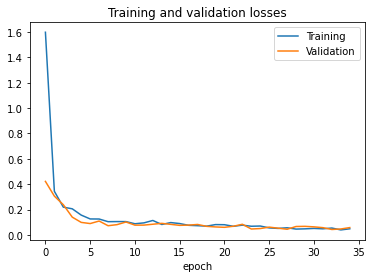

In [ ]:
# PLOT GRAPH BETWEEN TRAINING AND VALIDATION LOSS
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Training', 'Validation'])
plt.title("Training and validation losses")
plt.xlabel('epoch')

Text(0.5, 0, 'epoch')

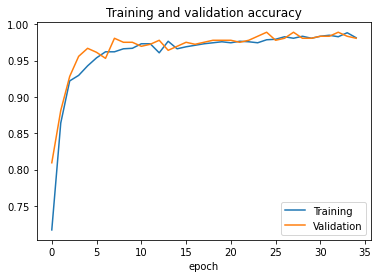

In [ ]:
# PLOT GRAPH BETWEEN TRAINING AND VALIDATION ACCURACY
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Training', 'Validation'])
plt.title("Training and validation accuracy")
plt.xlabel('epoch')

In [ ]:
# GETTING TEST ACCURACY AND LOSS

test_loss, test_acc = model.evaluate(test_generator)
print("Test Set Loss : ", test_loss)
print("Test Set Accuracy : ", test_acc)

16/16 [==============================] - 13s 838ms/step - loss: 0.0576 - accuracy: 0.9814
Test Set Loss :  0.05758047476410866
Test Set Accuracy :  0.9814049601554871


In [ ]:
model.save("model.h5")

In [ ]:
from google.colab import files
from keras.preprocessing import image

uploaded = files.upload()

for filename in uploaded.keys():
  img_path = '/content/' + filename
  img = image.load_img(img_path, target_size = (150,150))
  images = image.img_to_array(img)
  images = np.expand_dims(images, axis = 0)
  prediction = model.predict(images)

  if prediction == 0:
    print("The report is COVID-19 Positive")
  else:
    print("The report is COVID-19 Negative")